# The Efficient Frontier

## Imports

In [1]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta
from scipy.optimize import minimize

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-06-14 19:41:04.071 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [2]:
# Choose a random selection of 5 stocks
random.seed(100)
n_assets = 5
tickers = tao.select_n(n_assets, tad.get_sp500_tickers())
df_stocks = tad.load_data(tickers=tickers, start_date='2020-01-01')
ht(df_stocks)

[*********************100%***********************]  5 of 5 completed


Price           Close                                                \
Ticker            HAL          M        PAYC         SE        TROW   
Date                                                                  
2020-01-02  21.914686  13.186192  264.956390  40.040001   96.057739   
2020-01-03  21.985722  13.194174  265.843414  40.490002   95.743019   
2020-01-06  22.545130  13.649144  271.088013  40.480000   96.334000   
2026-06-10  39.730000  23.160000  136.720001  82.440002  106.430000   
2026-06-11  39.759998  25.040001  132.240005  85.690002  108.269997   
2026-06-12  39.599998  25.370001  134.520004  82.940002  109.639999   

Price            High                                                ...  \
Ticker            HAL          M        PAYC         SE        TROW  ...   
Date                                                                 ...   
2020-01-02  22.056759  13.784838  265.131881  41.189999   96.065410  ...   
2020-01-03  22.598410  13.258029  266.788992  40.650002   96.349328  ...   
2020-01-06  22.616166  13.776855  271.195258  41.029999   96.372376  ...   
2026-06-10  40.480000  23.549999  138.860001  84.199997  109.099998  ...   
2026-06-11  40.410000  25.049999  136.645004  85.709999  108.320000  ...   
2026-06-12  40.139999  25.650000  135.149994  86.650002  110.510002  ...   

Price            Open                                                  Volume  \
Ticker            HAL          M        PAYC         SE        TROW       HAL   
Date                                                                            
2020-01-02  21.923566  13.713001  260.199288  41.000000   93.901118   9125500   
2020-01-03  22.456337  13.026552  262.704490  39.439999   95.090663  11562600   
2020-01-06  22.198829  13.186191  261.154583  40.070000   95.290233  14422600   
2026-06-10  39.720001  22.090000  134.100006  83.910004  106.180000   7894500   
2026-06-11  40.310001  23.590000  133.490005  82.129997  106.889999  20808600   
2026-06-12  39.360001  25.100000  132.240005  86.110001  109.099998  10683100   

Price                                            
Ticker             M     PAYC       SE     TROW  
Date                                             
2020-01-02  26388100   388700  5857000  1399600  
2020-01-03  12026100   343200  5237800   958800  
2020-01-06  20253700   446600  4049200   771300  
2026-06-10   7956200   795800  4079200  2988600  
2026-06-11  10049500  1276900  2731500  2155700  
2026-06-12   7706600   857800  3426400  2020900  

[6 rows x 25 columns]

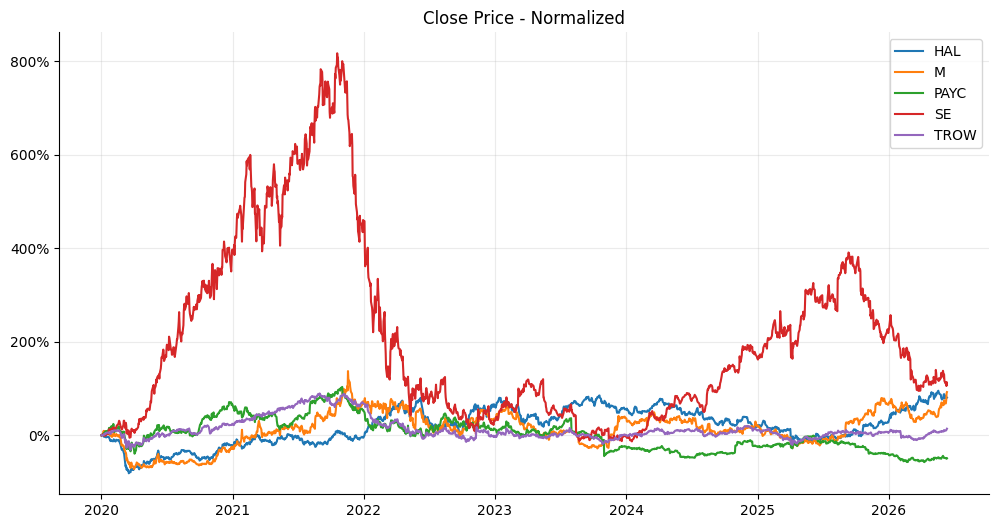

In [3]:
fig, ax = tap.trend(df_stocks, normalize=True)

## Compute Returns

In [4]:
df_returns = tao.calc_returns(df_stocks)
ht(df_returns)

Ticker,HAL,M,PAYC,SE,TROW
Date,,,,,
2020-01-03,0.003241,0.000605,0.003348,0.011239,-0.003276
2020-01-06,0.025444,0.034483,0.019728,-0.000247,0.006173
2020-01-07,-0.028358,0.033333,0.005034,0.013093,0.003983
2026-06-10,0.002776,0.044184,0.004260,-0.028632,0.004910
2026-06-11,0.000755,0.081174,-0.032768,0.039423,0.017288
2026-06-12,-0.004024,0.013179,0.017241,-0.032092,0.012654


In [5]:
tau.get_returns_summary(df_returns)

,Return,Risk,Sharpe
Ticker,,,
HAL,0.233544,0.524440,0.445321
M,0.296346,0.628608,0.471432
PAYC,0.014245,0.480990,0.029616
SE,0.317034,0.638795,0.496301
TROW,0.076472,0.335173,0.228158


## Generating Many Random Portfolios

In [57]:
cagr = ((1 + df_returns).prod())**(252/len(df_returns)) - 1
cagr

Ticker
HAL     0.096469
M       0.107226
PAYC   -0.100133
SE      0.120026
TROW    0.020799
dtype: float64

In [58]:
cov = df_returns.cov() * 252
cov

Ticker,HAL,M,PAYC,SE,TROW
Ticker,,,,,
HAL,0.275037,0.122710,0.075909,0.064376,0.075397
M,0.122710,0.395148,0.089107,0.083900,0.092299
PAYC,0.075909,0.089107,0.231352,0.120914,0.083136
SE,0.064376,0.083900,0.120914,0.408058,0.085321
TROW,0.075397,0.092299,0.083136,0.085321,0.112341


In [59]:
def portfolio_return(weights):
    return np.dot(weights, cagr)

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov @ weights)

def sharpe_ratio(weights, rf=0.04):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    return (ret - rf) / vol

In [60]:
n_random = 1000

rand_returns = []
rand_vols = []
rand_sharpes = []
rand_weights = []

for _ in range(n_random):

    weights = np.random.random(n_assets)
    weights /= np.sum(weights)

    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    sharpe = sharpe_ratio(weights)

    rand_returns.append(ret)
    rand_vols.append(vol)
    rand_sharpes.append(sharpe)
    rand_weights.append(weights)

In [61]:
portfolios = pd.DataFrame({'Return': rand_returns,
                            'Risk': rand_vols,
                            'Sharpe': rand_sharpes,
                            'Weights': rand_weights})

## Portfolio Strategies

#### Equal Weighted Portfolio

In [62]:
equal_weights = np.ones(n_assets) / n_assets
equal_weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [63]:
ewp_returns = df_returns.dot(equal_weights)

In [64]:
ewp_returns

Date
2020-01-03    0.003031
2020-01-06    0.017116
2020-01-07    0.005417
2020-01-08    0.000197
2020-01-09    0.001897
                ...   
2026-06-08   -0.000951
2026-06-09   -0.002644
2026-06-10    0.005500
2026-06-11    0.021175
2026-06-12    0.001391
Length: 1619, dtype: float64

#### Max Sharpe Portfolio (Tangent Portfolio)

In [65]:
bounds = tuple((0, 1) for _ in range(n_assets))

weight_constraint = {
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
}

# Our initial guess is a portfolio of equal weighting
initial_weights = np.ones(n_assets) / n_assets

In [66]:
rf = 0.04

max_sharpe = minimize(
    fun         = lambda w: -sharpe_ratio(w, rf),
    x0          = initial_weights,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = weight_constraint
)

w_max_sharpe = max_sharpe.x
w_max_sharpe

array([3.29469826e-01, 2.58639344e-01, 5.20417043e-18, 4.11890830e-01,
       0.00000000e+00])

In [68]:
msp_returns = df_returns.dot(w_max_sharpe)

#### Minimum-Variance Portfolio

In [69]:
bounds = tuple((0, 1) for _ in range(n_assets))

weight_constraint = {
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
}

# Our initial guess is a portfolio of equal weighting
initial_weights = np.ones(n_assets) / n_assets

# Minimize portfolio volatility
min_var = minimize(
    fun         = portfolio_volatility,
    x0          = initial_weights,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = weight_constraint
) 

w_min_var = min_var.x

In [70]:
w_min_var

array([0.13133178, 0.02210332, 0.12206278, 0.04745732, 0.6770448 ])

In [71]:
mvp_returns = df_returns.dot(w_min_var)

#### Plotting Portfolios

In [72]:
df_returns['EWP'] = ewp_returns
df_returns['MSP'] = msp_returns
df_returns['MVP'] = mvp_returns

In [73]:
df_returns

Ticker,HAL,M,PAYC,SE,TROW,EWP,MSP,MVP
Date,,,,,,,,
2020-01-03,0.003241,0.000605,0.003348,0.011239,-0.003276,0.003031,0.005854,-0.000837
2020-01-06,0.025444,0.034483,0.019728,-0.000247,0.006173,0.017116,0.017200,0.010679
2020-01-07,-0.028358,0.033333,0.005034,0.013093,0.003983,0.005417,0.004671,0.000945
2020-01-08,-0.025132,0.024335,0.012988,-0.020727,0.009522,0.000197,-0.010523,0.004286
2020-01-09,0.005821,-0.021547,0.007665,0.009213,0.008332,0.001897,0.000140,0.007302
...,...,...,...,...,...,...,...,...
2026-06-08,0.033691,0.004513,-0.013951,-0.023914,-0.005095,-0.000951,0.002417,-0.001763
2026-06-09,-0.021728,-0.003594,0.003242,0.004498,0.004362,-0.002644,-0.006236,0.000630
2026-06-10,0.002776,0.044184,0.004260,-0.028632,0.004910,0.005500,0.000549,0.003827


In [74]:
tau.get_returns_summary(df_returns)

,Return,Risk,Sharpe
Ticker,,,
HAL,0.233544,0.524440,0.445321
M,0.296346,0.628608,0.471432
PAYC,0.014245,0.480990,0.029616
SE,0.317034,0.638795,0.496301
TROW,0.076472,0.335173,0.228158
EWP,0.187528,0.358222,0.523497
MSP,0.284176,0.426355,0.666524
MVP,0.105782,0.319687,0.330891


In [75]:
target_returns = np.linspace(
    cagr.min(),
    cagr.max(),
    1000
)

frontier_vols = []

for target in target_returns:

    constraints = [
        weight_constraint,
        {
            "type": "eq",
            "fun": lambda w, target=target:
                portfolio_return(w) - target
        }
    ]

    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        frontier_vols.append(result.fun)
    else:
        frontier_vols.append(np.nan)

In [76]:
len(target_returns)

1000

In [77]:
len(frontier_vols)

1000

In [78]:
target_returns / frontier_vols

array([-2.08181808e-01, -2.07966304e-01, -2.07750049e-01, -2.07533040e-01,
       -2.07315274e-01, -2.07096748e-01, -2.06877460e-01, -2.06657406e-01,
       -2.06436585e-01, -2.06214992e-01, -2.05992626e-01, -2.05769484e-01,
       -2.05545563e-01, -2.05320860e-01, -2.05095372e-01, -2.04869097e-01,
       -2.04642031e-01, -2.04414172e-01, -2.04185517e-01, -2.03956063e-01,
       -2.03725808e-01, -2.03494748e-01, -2.03262880e-01, -2.03030203e-01,
       -2.02796712e-01, -2.02562405e-01, -2.02327280e-01, -2.02091332e-01,
       -2.01854560e-01, -2.01616960e-01, -2.01378530e-01, -2.01139267e-01,
       -2.00899167e-01, -2.00658228e-01, -2.00416446e-01, -2.00173820e-01,
       -1.99930346e-01, -1.99686021e-01, -1.99440841e-01, -1.99194805e-01,
       -1.98947910e-01, -1.98700151e-01, -1.98451527e-01, -1.98202033e-01,
       -1.97951669e-01, -1.97700429e-01, -1.97448312e-01, -1.97195314e-01,
       -1.96941432e-01, -1.96686664e-01, -1.96431006e-01, -1.96174456e-01,
       -1.95917010e-01, -

In [79]:
np.argmin(frontier_vols)

np.int64(557)

In [80]:
frontier_vols[250:270]

[np.float64(0.36486563370819947),
 np.float64(0.3645297262247916),
 np.float64(0.36419512675276944),
 np.float64(0.36386183891668933),
 np.float64(0.3635298662922153),
 np.float64(0.3631992124847628),
 np.float64(0.3628698811499185),
 np.float64(0.362541875841226),
 np.float64(0.3622152001600948),
 np.float64(0.36188985774255095),
 np.float64(0.3615658521701667),
 np.float64(0.36124318705881503),
 np.float64(0.360921865966387),
 np.float64(0.36060189250420355),
 np.float64(0.3602832702431349),
 np.float64(0.35996600283032293),
 np.float64(0.3596500937718706),
 np.float64(0.3593355467104422),
 np.float64(0.35902236522670133),
 np.float64(0.35871055283469566)]

(0.0, 0.6707342896864984)

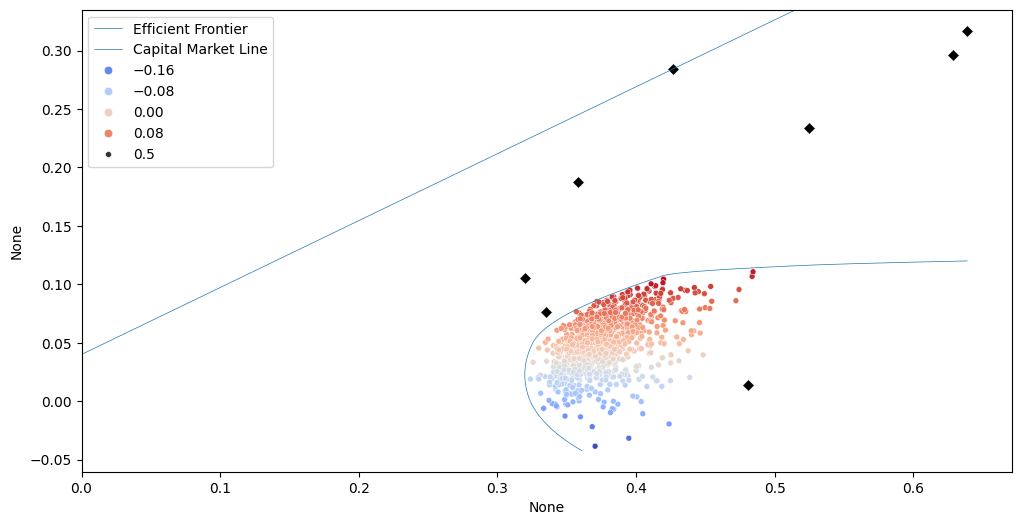

In [81]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    frontier_vols[262:],
    target_returns[262:],
    linewidth=0.5,
    label="Efficient Frontier"
)
ax.axline((0,rf), (df_returns['MSP'].std() * np.sqrt(252), df_returns['MSP'].mean() * 252), linewidth=0.5, label='Capital Market Line')

sns.scatterplot(y=rand_returns, x=rand_vols, hue=rand_sharpes, size=0.5, ax=ax, palette='coolwarm')
sns.scatterplot(y=df_returns.mean() * 252, x=df_returns.std() * np.sqrt(252), marker='D', color='black')

ax.set_xlim(0, ax.get_xlim()[1])
